Ok time for some exploration of the data. We're gonna need pandas for this. 

In [86]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
READ_DIR = Path("../") / "data" / "processed"

Ok lets import the csvs

In [88]:
flows_df = pd.read_csv(READ_DIR / 'flows.csv')
generation_df = pd.read_csv(READ_DIR / 'generation.csv')
prices_df = pd.read_csv(READ_DIR / 'prices.csv')

Data is there. Lets do a data quality pass.

In [89]:
flows_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   zone_from  1344 non-null   str    
 1   zone_to    1344 non-null   str    
 2   timestamp  1344 non-null   str    
 3   flow_mw    1344 non-null   float64
dtypes: float64(1), str(3)
memory usage: 42.1 KB


Ok, we convert all the timestamps into datetime format (.csv do not natively carry that), and force utc since we might be dealing with different time zones. We'll get rid of any misaligned stuff later by doing an inner merge.

In [90]:
# Convert the timestamp column to datetime
flows_df['timestamp'] = pd.to_datetime(flows_df['timestamp'], utc=True)
generation_df["timestamp"]=pd.to_datetime(generation_df["timestamp"], utc=True)
prices_df["timestamp"]=pd.to_datetime(prices_df["timestamp"], utc=True)

Lets check for duplicates.

In [91]:
flows_df[flows_df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

,zone_from,zone_to,timestamp,flow_mw
0,DE_LU,SE_4,2025-12-31 23:00:00+00:00,0.000000
672,SE_4,DE_LU,2025-12-31 23:00:00+00:00,216.864700
673,SE_4,DE_LU,2025-12-31 23:15:00+00:00,216.864685
1,DE_LU,SE_4,2025-12-31 23:15:00+00:00,0.000000
2,DE_LU,SE_4,2025-12-31 23:30:00+00:00,0.000000
...,...,...,...,...
669,DE_LU,SE_4,2026-01-07 22:15:00+00:00,0.000000
1342,SE_4,DE_LU,2026-01-07 22:30:00+00:00,216.693939
670,DE_LU,SE_4,2026-01-07 22:30:00+00:00,0.000000
671,DE_LU,SE_4,2026-01-07 22:45:00+00:00,0.000000


Yeah, thats to be expected, it uses the timestamp always twice each for each direction. Check.

In [92]:
generation_df[generation_df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

,zone,timestamp,production_type,value_mw
0,DE_LU,2025-12-31 23:00:00+00:00,Biomass,4210.669292
13440,SE_4,2025-12-31 23:00:00+00:00,Wind Onshore,825.139000
672,DE_LU,2025-12-31 23:00:00+00:00,Fossil Brown coal/Lignite,4364.732450
12096,SE_4,2025-12-31 23:00:00+00:00,Other,147.193000
2016,DE_LU,2025-12-31 23:00:00+00:00,Fossil Gas,6662.260660
...,...,...,...,...
1343,DE_LU,2026-01-07 22:45:00+00:00,Fossil Brown coal/Lignite,9112.325100
12767,SE_4,2026-01-07 22:45:00+00:00,Other,217.146000
671,DE_LU,2026-01-07 22:45:00+00:00,Biomass,4079.226876
9407,DE_LU,2026-01-07 22:45:00+00:00,Waste,722.844000


Again, once for each combination of region and production type.

In [93]:
prices_df[prices_df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-31 23:00:00+00:00,63.64
673,SE_4,2025-12-31 23:00:00+00:00,41.58
674,SE_4,2025-12-31 23:15:00+00:00,40.87
1,DE_LU,2025-12-31 23:15:00+00:00,61.48
2,DE_LU,2025-12-31 23:30:00+00:00,58.00
...,...,...,...
670,DE_LU,2026-01-07 22:30:00+00:00,86.83
1344,SE_4,2026-01-07 22:45:00+00:00,59.30
671,DE_LU,2026-01-07 22:45:00+00:00,84.10
672,DE_LU,2026-01-07 23:00:00+00:00,86.88


OK, fine, that also makes sense, since we do each region. Right.

Lets instead check more granularily:

In [94]:
flows_df[["zone_from", "zone_to", "timestamp"]].duplicated().sum()

np.int64(0)

In [95]:
generation_df[["zone", "timestamp", "production_type"]].duplicated().sum()

np.int64(0)

In [96]:
prices_df[["zone", "timestamp"]].duplicated().sum()

np.int64(0)

Ok, good, no duplicates we care about.

Lets do some individual analysis.

In [97]:
generation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14112 entries, 0 to 14111
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   zone             14112 non-null  str                
 1   timestamp        14112 non-null  datetime64[us, UTC]
 2   production_type  14112 non-null  str                
 3   value_mw         14112 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(1), str(2)
memory usage: 441.1 KB


Lets see if generation is positive always.

In [98]:
generation_df.sort_values("value_mw", ascending=True).head(10)

,zone,timestamp,production_type,value_mw
4918,DE_LU,2026-01-03 04:30:00+00:00,Hydro Pumped Storage,-6033.1901
4917,DE_LU,2026-01-03 04:15:00+00:00,Hydro Pumped Storage,-5900.1391
4916,DE_LU,2026-01-03 04:00:00+00:00,Hydro Pumped Storage,-5796.4269
4919,DE_LU,2026-01-03 04:45:00+00:00,Hydro Pumped Storage,-5746.5970
4915,DE_LU,2026-01-03 03:45:00+00:00,Hydro Pumped Storage,-5725.7873
4753,DE_LU,2026-01-01 11:15:00+00:00,Hydro Pumped Storage,-5542.2458
4755,DE_LU,2026-01-01 11:45:00+00:00,Hydro Pumped Storage,-5439.9287
4750,DE_LU,2026-01-01 10:30:00+00:00,Hydro Pumped Storage,-5425.9150
4754,DE_LU,2026-01-01 11:30:00+00:00,Hydro Pumped Storage,-5404.6995
4752,DE_LU,2026-01-01 11:00:00+00:00,Hydro Pumped Storage,-5378.3117


In [99]:
generation_df.loc[generation_df["value_mw"] < 0].value_counts("production_type")

production_type
Hydro Pumped Storage    347
Name: count, dtype: int64

Ok its just the pumped hydro. Nice.

In [100]:
prices_df

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-31 23:00:00+00:00,63.64
1,DE_LU,2025-12-31 23:15:00+00:00,61.48
2,DE_LU,2025-12-31 23:30:00+00:00,58.00
3,DE_LU,2025-12-31 23:45:00+00:00,49.99
4,DE_LU,2026-01-01 00:00:00+00:00,60.01
...,...,...,...
1341,SE_4,2026-01-07 22:00:00+00:00,67.26
1342,SE_4,2026-01-07 22:15:00+00:00,62.37
1343,SE_4,2026-01-07 22:30:00+00:00,60.56
1344,SE_4,2026-01-07 22:45:00+00:00,59.30


In [101]:
prices_df.loc[prices_df["price_eur_mwh"] < 0]

,zone,timestamp,price_eur_mwh
43,DE_LU,2026-01-01 09:45:00+00:00,-0.01
47,DE_LU,2026-01-01 10:45:00+00:00,-0.01
48,DE_LU,2026-01-01 11:00:00+00:00,-0.01
49,DE_LU,2026-01-01 11:15:00+00:00,-0.01
50,DE_LU,2026-01-01 11:30:00+00:00,-0.01
51,DE_LU,2026-01-01 11:45:00+00:00,-0.01
52,DE_LU,2026-01-01 12:00:00+00:00,-0.01
53,DE_LU,2026-01-01 12:15:00+00:00,-0.01
54,DE_LU,2026-01-01 12:30:00+00:00,-0.01
56,DE_LU,2026-01-01 13:00:00+00:00,-0.01


Yeah, that should be ok, a brief window of overcap.

In [102]:
flows_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   zone_from  1344 non-null   str                
 1   zone_to    1344 non-null   str                
 2   timestamp  1344 non-null   datetime64[us, UTC]
 3   flow_mw    1344 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), str(2)
memory usage: 42.1 KB


In [103]:
flows_df.sort_values("flow_mw", ascending=True).head(10)

,zone_from,zone_to,timestamp,flow_mw
1103,SE_4,DE_LU,2026-01-05 10:45:00+00:00,0.0
11,DE_LU,SE_4,2026-01-01 01:45:00+00:00,0.0
12,DE_LU,SE_4,2026-01-01 02:00:00+00:00,0.0
1074,SE_4,DE_LU,2026-01-05 03:30:00+00:00,0.0
1075,SE_4,DE_LU,2026-01-05 03:45:00+00:00,0.0
1076,SE_4,DE_LU,2026-01-05 04:00:00+00:00,0.0
1077,SE_4,DE_LU,2026-01-05 04:15:00+00:00,0.0
1078,SE_4,DE_LU,2026-01-05 04:30:00+00:00,0.0
1079,SE_4,DE_LU,2026-01-05 04:45:00+00:00,0.0
1080,SE_4,DE_LU,2026-01-05 05:00:00+00:00,0.0


Ok, no negative flows - they are always denoted by direction in pairs. Lets see later how i want the data, we could transform with directionality and negatives if we wanted.

In [104]:
print(generation_df.isna().sum())
print(prices_df.isna().sum())
print(flows_df.isna().sum())

zone               0
timestamp          0
production_type    0
value_mw           0
dtype: int64
zone             0
timestamp        0
price_eur_mwh    0
dtype: int64
zone_from    0
zone_to      0
timestamp    0
flow_mw      0
dtype: int64


No flows, ok so the data quality pass is done. Wait, length.

In [105]:
print(len(generation_df), len(prices_df), len(flows_df))

14112 1346 1344


In [106]:
prices_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   zone           1346 non-null   str                
 1   timestamp      1346 non-null   datetime64[us, UTC]
 2   price_eur_mwh  1346 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), str(1)
memory usage: 31.7 KB


In [107]:
print(prices_df["timestamp"].max())
print(prices_df["timestamp"].min())
print(flows_df["timestamp"].max())
print(flows_df["timestamp"].min())
print(generation_df["timestamp"].max())
print(generation_df["timestamp"].min())

2026-01-07 23:00:00+00:00
2025-12-31 23:00:00+00:00
2026-01-07 22:45:00+00:00
2025-12-31 23:00:00+00:00
2026-01-07 22:45:00+00:00
2025-12-31 23:00:00+00:00


Seems generation and flows has an extra timestamp in the beginning. Should still be fine. I want it wide again to count to be sure.

In [108]:
generation_wide_df = generation_df.pivot(index=['zone','timestamp'], columns='production_type', values='value_mw')

In [109]:
generation_wide_df[generation_wide_df.isna().any(axis=1)].index.get_level_values('zone')

Index(['SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4',
       'SE_4',
       ...
       'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4',
       'SE_4'],
      dtype='str', name='zone', length=672)

Right, so we have a bunch of NaNs in the swedish rows, as expected (they dont burn coal for example). The count checks out though.

Thats a quick data quality check done. Lets run some naive analyses to check feasibility of the entire project.

<Axes: xlabel='timestamp', ylabel='price_eur_mwh'>

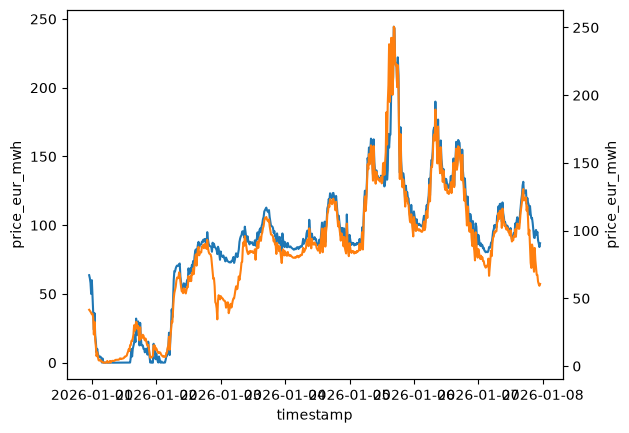

In [110]:
fig, ax1 = plt.subplots()
sns.lineplot(data=prices_df[prices_df.zone=='DE_LU'], x='timestamp', y='price_eur_mwh', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=prices_df[prices_df.zone=='SE_4'], x='timestamp', y='price_eur_mwh', ax=ax2, color='tab:orange')

In [111]:
flows_df.head()

,zone_from,zone_to,timestamp,flow_mw
0,DE_LU,SE_4,2025-12-31 23:00:00+00:00,0.0
1,DE_LU,SE_4,2025-12-31 23:15:00+00:00,0.0
2,DE_LU,SE_4,2025-12-31 23:30:00+00:00,0.0
3,DE_LU,SE_4,2025-12-31 23:45:00+00:00,0.0
4,DE_LU,SE_4,2026-01-01 00:00:00+00:00,0.0


<Axes: xlabel='timestamp', ylabel='flow_mw'>

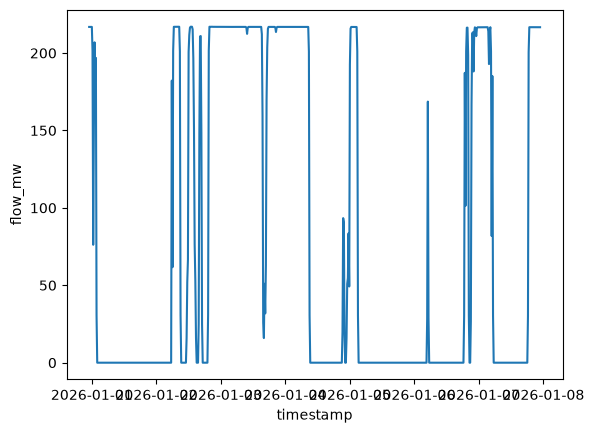

In [115]:
fig, ax3 = plt.subplots()
sns.lineplot(data=flows_df[flows_df["zone_from"]=='SE_4'], x='timestamp', y='flow_mw', ax=ax3, color='tab:blue')

<Axes: xlabel='timestamp', ylabel='flow_mw'>

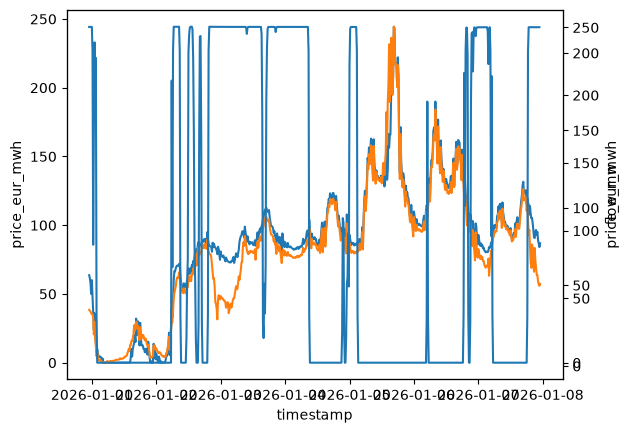

In [116]:
fig, ax1 = plt.subplots()
sns.lineplot(data=prices_df[prices_df.zone=='DE_LU'], x='timestamp', y='price_eur_mwh', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=prices_df[prices_df.zone=='SE_4'], x='timestamp', y='price_eur_mwh', ax=ax2, color='tab:orange')
ax3 = ax1.twinx()
sns.lineplot(data=flows_df[flows_df["zone_from"]=='SE_4'], x='timestamp', y='flow_mw', ax=ax3, color='tab:blue')

Yes, its ugly as can be with all three graphs overlaid, but yes, we see a decoupling with lower prices in sweden when the flow cap is reached. Really cool. We'd need to check transfer over Denmark for a complete analysis, but this is a cool indication.